# CIFAR-10 Data Augmentation

This notebook studies augmentation through `ImageDataGenerator`, standalone image
transformations, Keras augmentation layers, combined augmentations, mirrored data, and
test-time augmented prediction.

## ImageDataGenerator and Standalone Transformations

Keras ImageDataGenerator class provides a quick and easy way to augment your images.

The documentation can be found here: https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image/ImageDataGenerator

Let's first repeat the CIFAR-10 experiment using an image generator instead of the dataset.

In [1]:
import tensorflow as tf
from tensorflow.keras.regularizers import *
from tensorflow.keras.layers import *
from tensorflow.keras.losses import *
from tensorflow.keras.activations import *
from keras.utils import plot_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score, confusion_matrix,mean_squared_error,mean_absolute_error

import time
import numpy as np
import os

import matplotlib.pyplot as plt

from keras.models import Model
from keras.optimizers import SGD, Adam
from keras.regularizers import l2

from sklearn.metrics import accuracy_score

In [2]:
def plot_results(history):
  fig, ax = plt.subplots(ncols=2, figsize=(12,4))
  ax[0].plot(history.history['accuracy'],label = 'train')
  ax[0].plot(history.history['val_accuracy'],label = 'test')
  ax[0].set_title('Accuracy')
  ax[0].legend(loc='lower right')
  ax[1].plot(history.history['loss'],label = 'train')
  ax[1].plot(history.history['val_loss'],label = 'test')
  ax[1].set_title('Loss')
  ax[1].legend(loc='upper right')
  plt.show()

def print_best_metrics(h):
  labels = ['training accuracy', 'validation accuracy', 'training loss', 'validation loss']
  keys = ['accuracy', 'val_accuracy', 'loss', 'val_loss']
  prefix = ['highest','lowest']
  for i in range(4):
    metric = np.array(h[keys[i]])
    am = np.argmax((1.5-i)*metric)
    print(f'The {prefix[i//2]} {labels[i]} was {metric[am]:.4f} obtained in epoch {am+1}')
    print(f'The final {labels[i]} was {metric[-1]:.4f}')

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2201s 13us/step


In [4]:
datagen = ImageDataGenerator()
batch_size = 256
gen_cifar10 = datagen.flow(x_train, y_train,batch_size = batch_size) # Notice that batch_size is now part of the generator

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 551,978 (2.11 MB)

 Trainable params: 551,274 (2.10 MB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/50
195/195 - 24s - 125ms/step - accuracy: 0.4619 - loss: 1.5293 - val_accuracy: 0.1218 - val_loss: 5.4730
Epoch 2/50


/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


195/195 - 1s - 4ms/step - accuracy: 0.6289 - loss: 1.0907 - val_accuracy: 0.1266 - val_loss: 5.4480
Epoch 3/50
195/195 - 2s - 12ms/step - accuracy: 0.6530 - loss: 0.9805 - val_accuracy: 0.1137 - val_loss: 5.8549
Epoch 4/50
195/195 - 1s - 4ms/step - accuracy: 0.7383 - loss: 0.7845 - val_accuracy: 0.1413 - val_loss: 4.9738
Epoch 5/50
195/195 - 2s - 12ms/step - accuracy: 0.7263 - loss: 0.7786 - val_accuracy: 0.6020 - val_loss: 1.2084
Epoch 6/50
195/195 - 1s - 4ms/step - accuracy: 0.7383 - loss: 0.7292 - val_accuracy: 0.6311 - val_loss: 1.1199
Epoch 7/50
195/195 - 2s - 13ms/step - accuracy: 0.7692 - loss: 0.6611 - val_accuracy: 0.7524 - val_loss: 0.7152
Epoch 8/50
195/195 - 1s - 4ms/step - accuracy: 0.7617 - loss: 0.6573 - val_accuracy: 0.7475 - val_loss: 0.7451
Epoch 9/50
195/195 - 2s - 13ms/step - accuracy: 0.7973 - loss: 0.5799 - val_accuracy: 0.7448 - val_loss: 0.7766
Epoch 10/50
195/195 - 1s - 4ms/step - accuracy: 0.7734 - loss: 0.6316 - val_accuracy: 0.7719 - val_loss: 0.6706
Epoch 1

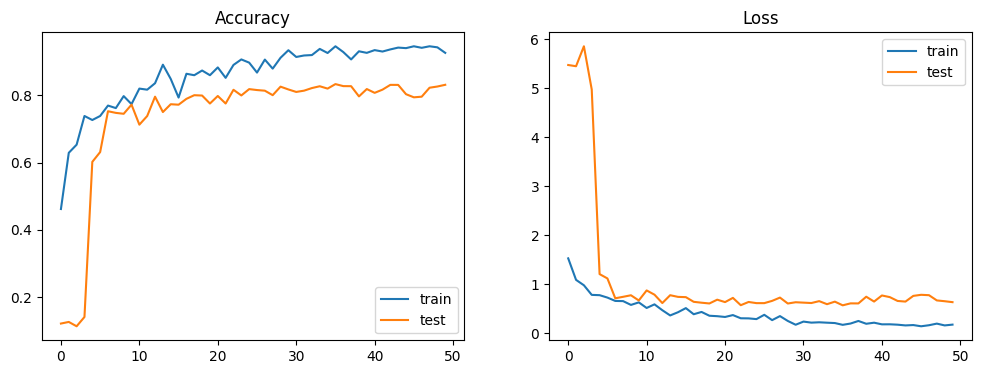

Model accuracy on test set: 0.8309
Model accuracy on mirrored test set: 0.8171
Model accuracy on combined original and mirrored test set: 0.8453


In [5]:
def vgg_dropout_bn(input_shape=(32,32,3),blocks=3,branching_factor=2,first_layer_filters=32,dropout=0.2,dense_layer=128):
  model = tf.keras.models.Sequential()
  f = first_layer_filters
  for i in range(blocks):
    if i==0:
      model.add(Conv2D(f, kernel_size=(3, 3), input_shape=input_shape, padding='same', activation="relu"))
    else:
      model.add(Conv2D(f, kernel_size=(3, 3), padding='same', activation='relu'))
    model.add(Conv2D(f, kernel_size=(3, 3), padding='same', activation='relu'))
    model.add(MaxPooling2D((2, 2)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout))
    f = int(f*branching_factor)
  model.add(Flatten())
  if dense_layer>0:
    model.add(Dense(128, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(dropout))
  model.add(Dense(10))
  model.add(Activation('softmax'))
  return model

model = vgg_dropout_bn()
model.summary()
model.compile(loss=CategoricalCrossentropy(), metrics=["accuracy"])

history = model.fit(
    gen_cifar10,
    epochs =  50,
    steps_per_epoch = x_train.shape[0]//batch_size,
    verbose = 2,
    validation_data=(x_test, y_test),
)

print_best_metrics(history.history)
plot_results(history)

pred1 = model(x_test).numpy()
pred2 = model(x_test[:,:,::-1]).numpy()

y_test_class =  np.argmax(y_test,axis=1)
print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_test_class)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_test_class)))

pred = np.argmax(pred1+pred2,axis=1)
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(pred,y_test_class)))

Now we will use the data augmentation capabilities of the generator.

In [6]:
datagen2 =  ImageDataGenerator(horizontal_flip=True,width_shift_range=[-2,2],height_shift_range=[-2,2],rotation_range=20, zoom_range=[0.75,1.0])
batch_size = 256
gen_cifar10_aug = datagen2.flow(x_train, y_train,batch_size = batch_size) # Notice that batch_size is now part of the generator

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 551,978 (2.11 MB)

 Trainable params: 551,274 (2.10 MB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/50
195/195 - 41s - 211ms/step - accuracy: 0.3962 - loss: 1.7287 - val_accuracy: 0.1036 - val_loss: 4.3607
Epoch 2/50


/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


195/195 - 1s - 4ms/step - accuracy: 0.5078 - loss: 1.3892 - val_accuracy: 0.1164 - val_loss: 3.5934
Epoch 3/50
195/195 - 27s - 138ms/step - accuracy: 0.5433 - loss: 1.2744 - val_accuracy: 0.1363 - val_loss: 4.3603
Epoch 4/50
195/195 - 1s - 4ms/step - accuracy: 0.5977 - loss: 1.1389 - val_accuracy: 0.1426 - val_loss: 3.9180
Epoch 5/50
195/195 - 27s - 137ms/step - accuracy: 0.6138 - loss: 1.0917 - val_accuracy: 0.5690 - val_loss: 1.2687
Epoch 6/50
195/195 - 1s - 4ms/step - accuracy: 0.6562 - loss: 0.9529 - val_accuracy: 0.5472 - val_loss: 1.3303
Epoch 7/50
195/195 - 27s - 138ms/step - accuracy: 0.6544 - loss: 0.9855 - val_accuracy: 0.6316 - val_loss: 1.1523
Epoch 8/50
195/195 - 1s - 4ms/step - accuracy: 0.6367 - loss: 0.9431 - val_accuracy: 0.6668 - val_loss: 1.0479
Epoch 9/50
195/195 - 27s - 137ms/step - accuracy: 0.6812 - loss: 0.9025 - val_accuracy: 0.6778 - val_loss: 0.9585
Epoch 10/50
195/195 - 1s - 4ms/step - accuracy: 0.6797 - loss: 0.9778 - val_accuracy: 0.6837 - val_loss: 0.9560

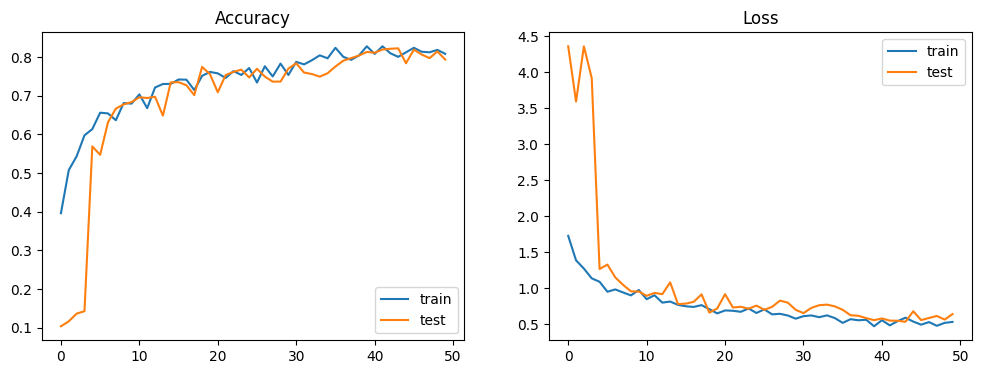

Model accuracy on test set: 0.7936
Model accuracy on mirrored test set: 0.7945
Model accuracy on combined original and mirrored test set: 0.8035


In [7]:
model = vgg_dropout_bn()
model.summary()
model.compile(loss=CategoricalCrossentropy(), metrics=["accuracy"])

history = model.fit(
    gen_cifar10_aug,
    epochs =  50,
    steps_per_epoch = x_train.shape[0]//batch_size,
    verbose = 2,
    validation_data=(x_test, y_test),
)

print_best_metrics(history.history)
plot_results(history)

pred1 = model(x_test).numpy()
pred2 = model(x_test[:,:,::-1]).numpy()

y_test_class =  np.argmax(y_test,axis=1)
print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_test_class)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_test_class)))

pred = np.argmax(pred1+pred2,axis=1)
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(pred,y_test_class)))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 551,978 (2.11 MB)

 Trainable params: 551,274 (2.10 MB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/100
195/195 - 42s - 216ms/step - accuracy: 0.4026 - loss: 1.7001 - val_accuracy: 0.1082 - val_loss: 4.0811
Epoch 2/100


/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


195/195 - 1s - 4ms/step - accuracy: 0.4648 - loss: 1.5079 - val_accuracy: 0.1459 - val_loss: 4.4033
Epoch 3/100
195/195 - 27s - 139ms/step - accuracy: 0.5484 - loss: 1.2641 - val_accuracy: 0.1024 - val_loss: 6.4106
Epoch 4/100
195/195 - 1s - 4ms/step - accuracy: 0.5859 - loss: 1.1710 - val_accuracy: 0.1102 - val_loss: 6.0237
Epoch 5/100
195/195 - 27s - 139ms/step - accuracy: 0.6200 - loss: 1.0796 - val_accuracy: 0.3736 - val_loss: 2.2512
Epoch 6/100
195/195 - 1s - 4ms/step - accuracy: 0.6680 - loss: 0.9753 - val_accuracy: 0.3607 - val_loss: 2.3014
Epoch 7/100
195/195 - 27s - 139ms/step - accuracy: 0.6587 - loss: 0.9696 - val_accuracy: 0.6159 - val_loss: 1.1713
Epoch 8/100
195/195 - 1s - 4ms/step - accuracy: 0.6719 - loss: 0.9775 - val_accuracy: 0.6787 - val_loss: 0.9349
Epoch 9/100
195/195 - 27s - 139ms/step - accuracy: 0.6835 - loss: 0.9000 - val_accuracy: 0.7064 - val_loss: 0.8500
Epoch 10/100
195/195 - 1s - 4ms/step - accuracy: 0.7070 - loss: 0.8983 - val_accuracy: 0.7138 - val_loss

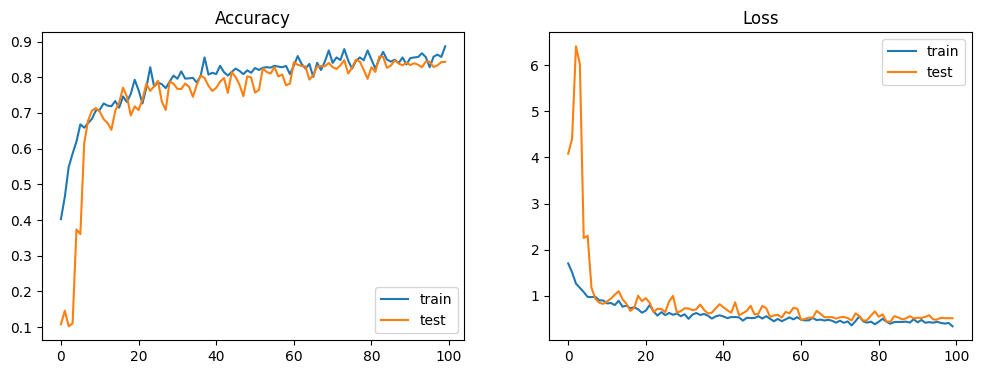

Model accuracy on test set: 0.8431
Model accuracy on mirrored test set: 0.8421
Model accuracy on combined original and mirrored test set: 0.8480


In [8]:
model = vgg_dropout_bn()
model.summary()
model.compile(loss=CategoricalCrossentropy(), metrics=["accuracy"])

history = model.fit(
    gen_cifar10_aug,
    epochs =  100,
    steps_per_epoch = x_train.shape[0]//batch_size,
    verbose = 2,
    validation_data=(x_test, y_test),
)

print_best_metrics(history.history)
plot_results(history)

pred1 = model(x_test).numpy()
pred2 = model(x_test[:,:,::-1]).numpy()

y_test_class =  np.argmax(y_test,axis=1)
print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_test_class)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_test_class)))

pred = np.argmax(pred1+pred2,axis=1)
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(pred,y_test_class)))

## Standalone Image Augmentation Demonstration

*Example adapted from an external Medium tutorial referenced in the source material.*

Saving House.png to House.png


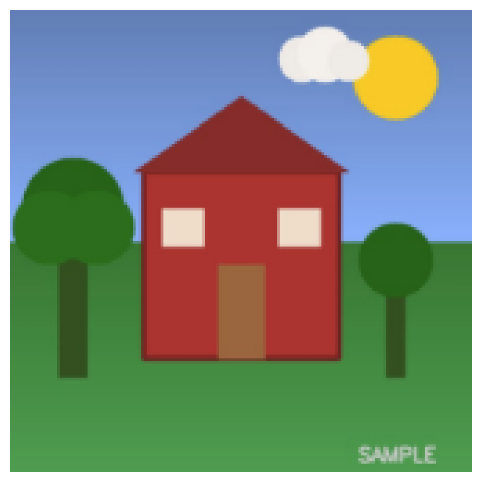

In [19]:
from google.colab import files
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt

# Upload an image from your computer for the augmentation demonstration.
uploaded = files.upload()
image_path = next(iter(uploaded))

img = tf.keras.preprocessing.image.load_img(image_path, target_size=(500, 500))
img_tensor = tf.keras.preprocessing.image.img_to_array(img)
img_tensor = np.expand_dims(img_tensor, axis=0)
img_tensor /= 255.0

plt.figure(figsize=(6, 6))
plt.imshow(img_tensor[0])
plt.axis("off")
plt.show()

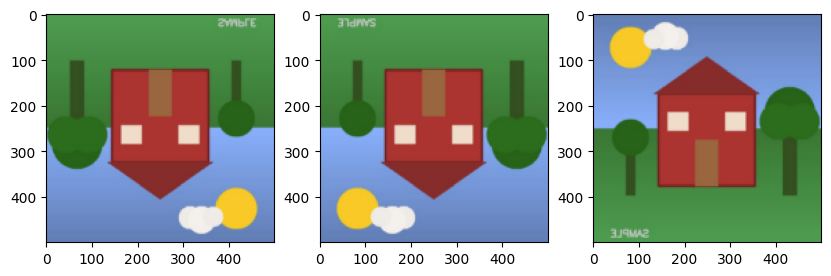

In [20]:
#Horizontal & Vertical Flip
img = tf.keras.preprocessing.image.load_img(image_path, target_size= (500,500))
img_tensor = tf.keras.preprocessing.image.img_to_array(img)
img_tensor = np.expand_dims(img_tensor, axis=0)#Uses ImageDataGenerator to flip the images
datagen = ImageDataGenerator(horizontal_flip=True, vertical_flip=True)#Creates our batch of one image
pic = datagen.flow(img_tensor, batch_size =1)
plt.figure(figsize=(10,8))#Plots our figures
for i in range(1,4):
  plt.subplot(1, 3, i)
  batch = next(pic)
  image_ = batch[0].astype('uint8')
  plt.imshow(image_)
plt.show()

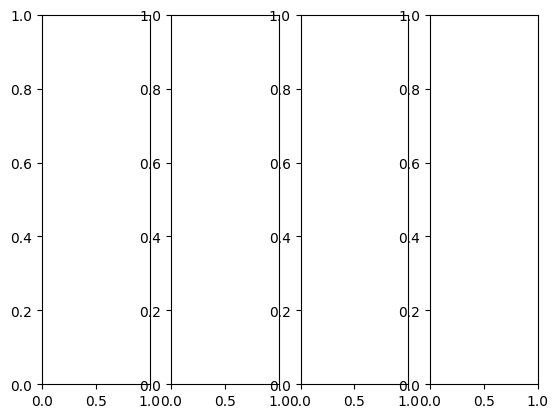

In [21]:
#Width Shift Range
datagen = ImageDataGenerator(width_shift_range=[-150, 150])#I also increased the number of plots
for i in range(1,5):
  plt.subplot(1, 4, i)

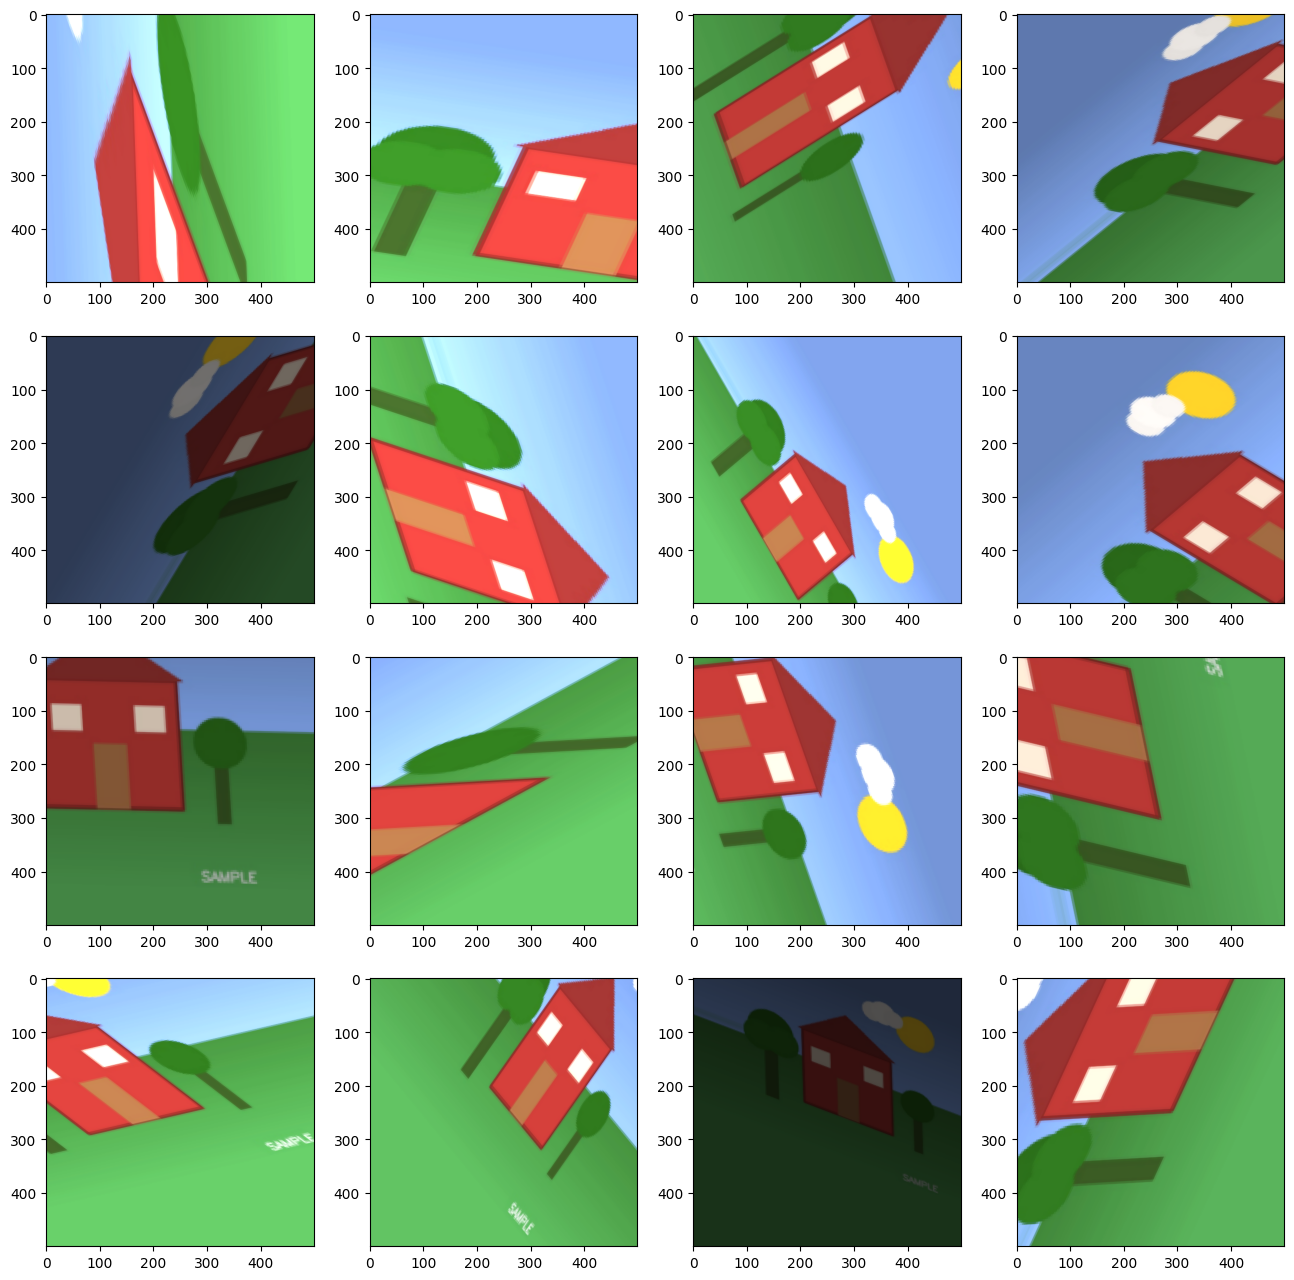

In [22]:
#Bringing It All Together Now

img = tf.keras.preprocessing.image.load_img(image_path, target_size= (500,500))
img_tensor = tf.keras.preprocessing.image.img_to_array(img)
img_tensor = np.expand_dims(img_tensor, axis=0)#Uses ImageDataGenerator to flip the images
datagen = ImageDataGenerator(width_shift_range=[-100, 100],
                    height_shift_range=[-100, 100],
                    rotation_range=120, brightness_range=[0.2, 1.5],
                    zoom_range = [0.3, 1.5] ,shear_range=50)#Creates our batch of one image
pic = datagen.flow(img_tensor, batch_size =1)
plt.figure(figsize=(16, 16))#Plots our figures
for i in range(1,17):
   plt.subplot(4, 4, i)
   batch = next(pic)
   image_ = batch[0].astype('uint8')
   plt.imshow(image_)
plt.show()

## Keras Augmentation Layers and Combined CIFAR-10 Training

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.losses import *
from tensorflow.keras.activations import *
from keras.utils import plot_model
from keras import callbacks, regularizers
import time
from sklearn.metrics import accuracy_score, confusion_matrix,mean_squared_error,mean_absolute_error

## Image Augmentation Layers
Keras provides several layers for image data augmentation that can be included as part of the neural network model. This allows to generate augmented images "on-the-fly", as the model is trained. In principle, we could have an infinite number of training images detived from the original dataset.

See the documentation here: https://keras.io/api/layers/preprocessing_layers/image_augmentation/

In [24]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train = np.float32(x_train/255.0)
x_test = np.float32(x_test/255.0)

In [25]:
X_train, X_test = x_train, x_test

We will implement several one-layer models, each implementing a different augmentation.

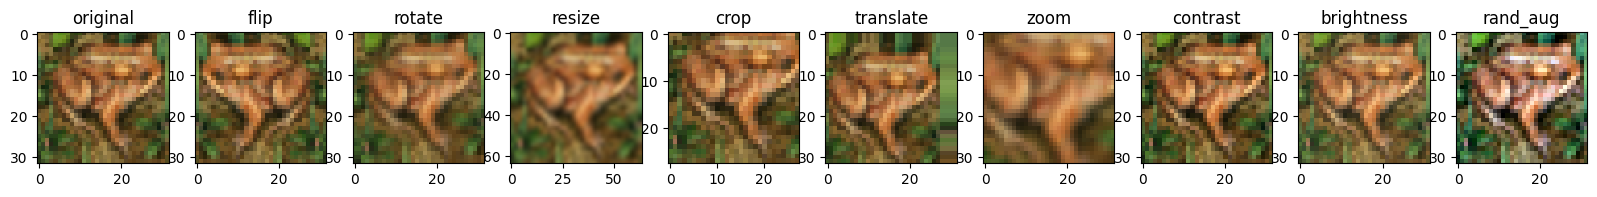

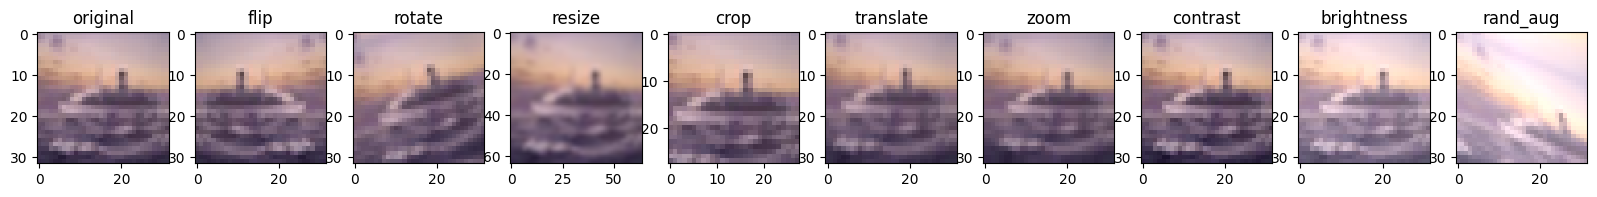

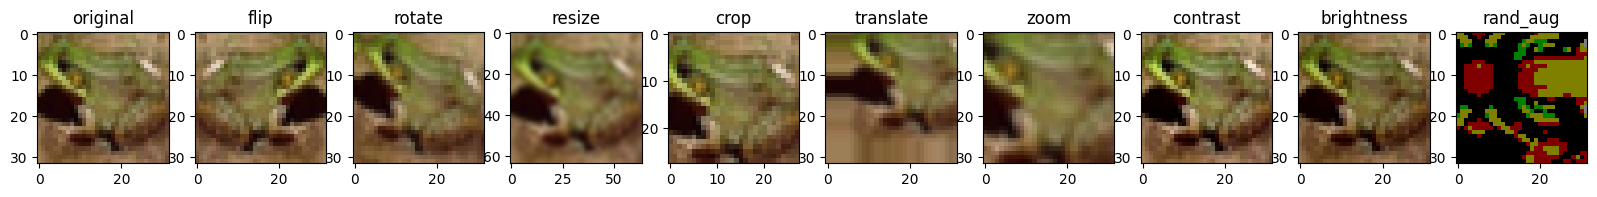

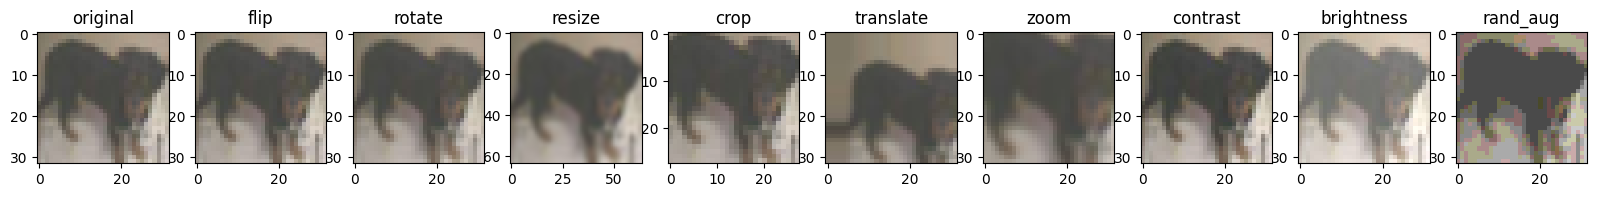

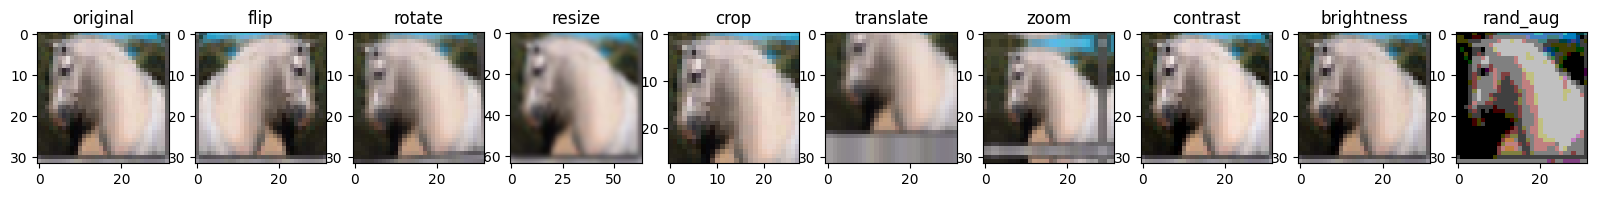

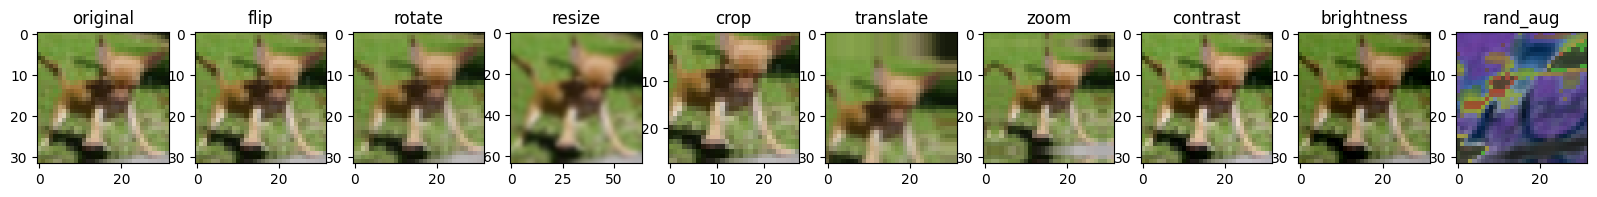

In [26]:
n = 6
sel = np.random.randint(0,x_train.shape[0],size = n)
batch = x_train[sel]

models = {}

models['flip'] = tf.keras.Sequential([RandomFlip("horizontal")])

models['rotate'] = tf.keras.Sequential([RandomRotation(0.05)])

models['resize'] = tf.keras.Sequential([Resizing(64, 64)])

models['crop'] = tf.keras.Sequential([RandomCrop(28,28)])

models['translate'] = tf.keras.Sequential([RandomTranslation(0.2,0.2,fill_mode='nearest')])

models['zoom'] = tf.keras.Sequential([RandomZoom(0.4)])

models['contrast'] = tf.keras.Sequential([RandomContrast(0.2,value_range=(0, 1))])

models['brightness'] = tf.keras.Sequential([RandomBrightness(0.2,value_range=(0.,1.))])

models['rand_aug'] = tf.keras.Sequential([RandAugment(value_range=(0, 1))])

for i in range(batch.shape[0]):
  fig, ax = plt.subplots(nrows=1,ncols=len(models)+1, figsize=(20,6))
  ax[0].imshow(batch[i])
  ax[0].title.set_text('original')
  for k,m in enumerate(models):
    model = models[m]
    aug = model(batch[i:i+1])
    #print(m,np.min(aug),np.max(aug))
    #for k,img in enumerate(aug):
    ax[k+1].imshow(aug[0])
    ax[k+1].title.set_text(m)
plt.show()

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_3 (RandomFlip)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_5               │ ?                      │   0 (unbuilt) │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_3 (RandomZoom)      │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

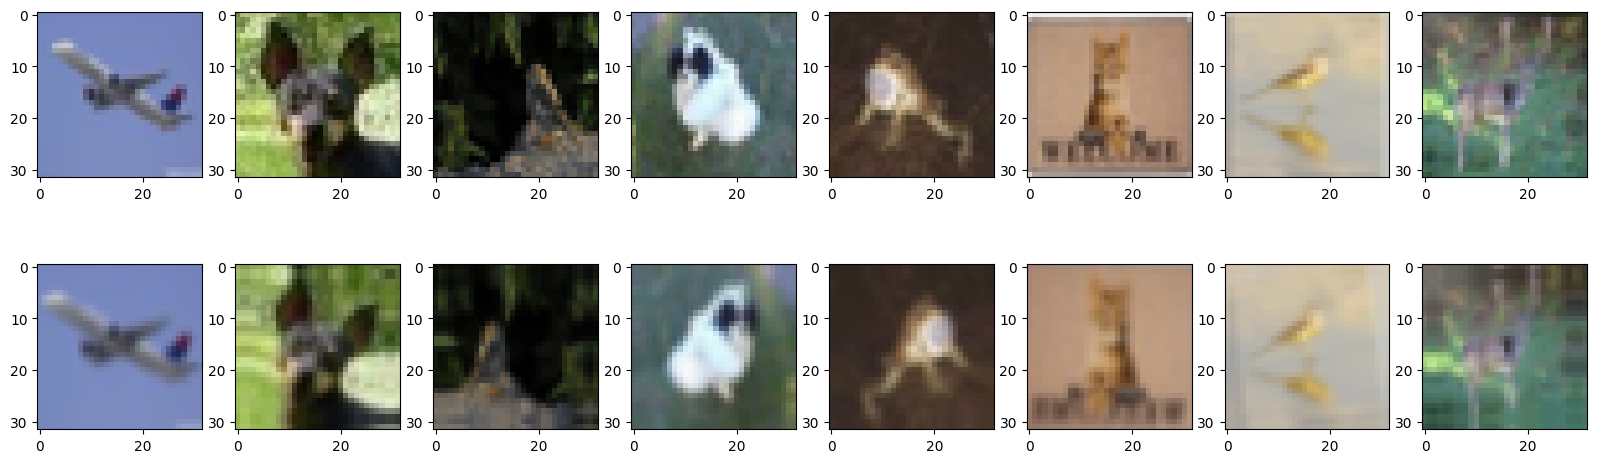

In [27]:
augmentation_layers = [RandomFlip("horizontal"), RandomRotation(0.05), RandomZoom(0.2)]

model_aug = tf.keras.Sequential(augmentation_layers)
model_aug.summary()

n = 8
sel = np.random.randint(0,x_train.shape[0],size = n)
batch = x_train[sel]

img_aug = model_aug(batch)
fig, ax = plt.subplots(nrows=2,ncols=n, figsize=(20,6))
for i in range(n):
  ax[0,i].imshow(batch[i])
  ax[1,i].imshow(img_aug[i])

plt.show()

Now we will build a model to classify the CIFAR-10 dataset that includes data augmentation "on-the-fly".

Number of classes: 10


Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_3 (RandomFlip)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_5               │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_3 (RandomZoom)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 32, 32, 50)     │         1,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 32, 32, 50)     │        22,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 16, 16, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 16, 16, 50)     │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 16, 16, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 16, 16, 100)    │        45,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 16, 16, 100)    │        90,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 8, 8, 100)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 8, 8, 100)      │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 8, 8, 100)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 8, 8, 200)      │       180,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 8, 8, 200)      │       360,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 4, 4, 200)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 4, 4, 200)      │           800 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 4, 4, 200)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 100)            │       320,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,022,460 (3.90 MB)

 Trainable params: 1,021,560 (3.90 MB)

 Non-trainable params: 900 (3.52 KB)


Original training images: (50000, 32, 32, 3)
Original training labels: (50000, 1)
Augmented training images: (100000, 32, 32, 3)
Augmented training labels: (100000, 1)
Epoch 1/100
1000/1000 - 16s - 16ms/step - accuracy: 0.5158 - loss: 1.3728 - val_accuracy: 0.5542 - val_loss: 1.4109
Epoch 2/100
1000/1000 - 10s - 10ms/step - accuracy: 0.6777 - loss: 0.9183 - val_accuracy: 0.6513 - val_loss: 1.0277
Epoch 3/100
1000/1000 - 10s - 10ms/step - accuracy: 0.7301 - loss: 0.7759 - val_accuracy: 0.7049 - val_loss: 0.8785
Epoch 4/100
1000/1000 - 10s - 10ms/step - accuracy: 0.7610 - loss: 0.6900 - val_accuracy: 0.7790 - val_loss: 0.6784
Epoch 5/100
1000/1000 - 10s - 10ms/step - accuracy: 0.7820 - loss: 0.6274 - val_accuracy: 0.7674 - val_loss: 0.7045
Epoch 6/100
1000/1000 - 10s - 10ms/step - accuracy: 0.8005 - loss: 0.5812 - val_accuracy: 0.8165 - val_loss: 0.5445
Epoch 7/100
1000/1000 - 10s - 10ms/step - accuracy: 0.8108 - loss: 0.5467 - val_accuracy: 0.8102 - val_loss: 0.5611
Epoch 8/100
1000/10

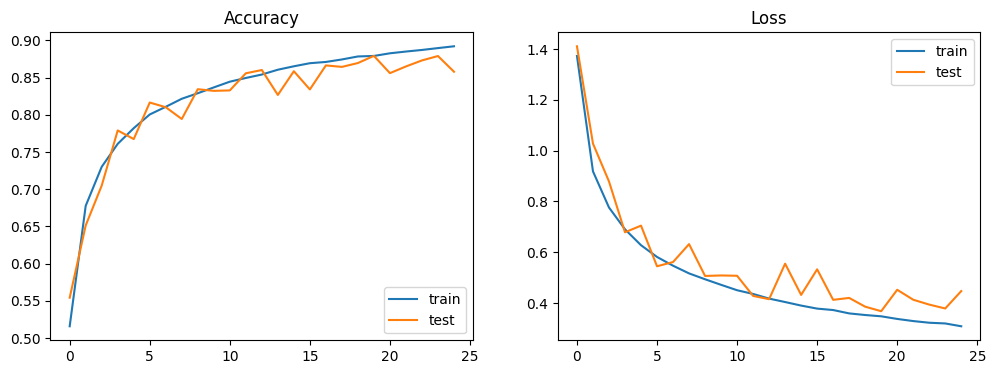

Model accuracy on original test set: 0.8792
Model accuracy on mirrored test set: 0.8772
Model accuracy on combined original and mirrored test set: 0.8894


In [30]:
earlystopping = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)


def cnn(
    input_shape,
    conv_units,
    dense_units,
    out_units,
    augmentation_layers=None,
    dropout_rate=0.2
):

    model = tf.keras.Sequential()

    model.add(Input(shape=input_shape))

    # Add augmentation layers, if provided
    if augmentation_layers is not None:
        for layer in augmentation_layers:
            model.add(layer)

    # Convolutional blocks
    for c in conv_units:

        model.add(
            Conv2D(
                c,
                kernel_size=(3, 3),
                activation='relu',
                padding='same'
            )
        )

        model.add(
            Conv2D(
                c,
                kernel_size=(3, 3),
                activation='relu',
                padding='same'
            )
        )

        model.add(
            MaxPooling2D(
                pool_size=(2, 2)
            )
        )

        model.add(
            BatchNormalization()
        )

        model.add(
            Dropout(dropout_rate)
        )

    # Fully connected layers
    model.add(
        Flatten()
    )

    model.add(
        Dense(
            dense_units,
            activation='relu'
        )
    )

    model.add(
        BatchNormalization()
    )

    model.add(
        Dropout(dropout_rate)
    )

    model.add(
        Dense(
            out_units,
            activation='softmax'
        )
    )

    return model


# --------------------------------------------------
# Number of CIFAR-10 classes
# --------------------------------------------------

num_classes = int(np.max(y_train) + 1)

print("Number of classes:", num_classes)


# --------------------------------------------------
# Build the model
# --------------------------------------------------

model = cnn(
    input_shape=X_train.shape[1:],
    conv_units=[50, 100, 200],
    dense_units=100,
    out_units=num_classes,
    augmentation_layers=augmentation_layers,
    dropout_rate=0.25
)

model.summary()


# --------------------------------------------------
# Compile the model
# --------------------------------------------------

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# --------------------------------------------------
# Add horizontally mirrored training images
# --------------------------------------------------

X_train_aug = np.append(
    X_train,
    X_train[:, :, ::-1],
    axis=0
)

y_train_aug = np.append(
    y_train,
    y_train,
    axis=0
)


print("\nOriginal training images:", X_train.shape)
print("Original training labels:", y_train.shape)

print("Augmented training images:", X_train_aug.shape)
print("Augmented training labels:", y_train_aug.shape)


# --------------------------------------------------
# Train the model
# --------------------------------------------------

start_train = time.time()

history = model.fit(
    X_train_aug,
    y_train_aug,
    epochs=100,
    batch_size=100,
    verbose=2,
    validation_data=(X_test, y_test),
    callbacks=[earlystopping]
)

end_train = time.time()


print(
    'Elapsed time training = {:.4f} secs'.format(
        end_train - start_train
    )
)

plot_results(history)


# --------------------------------------------------
# Prediction on original test images
# --------------------------------------------------

pred1 = model.predict(
    X_test,
    verbose=0
)

pred1_class = np.argmax(
    pred1,
    axis=1
)

accuracy_original = accuracy_score(
    y_test.ravel(),
    pred1_class
)

print(
    'Model accuracy on original test set: {:.4f}'.format(
        accuracy_original
    )
)


# --------------------------------------------------
# Prediction on mirrored test images
# --------------------------------------------------

X_test_mirrored = X_test[:, :, ::-1]

pred2 = model.predict(
    X_test_mirrored,
    verbose=0
)

pred2_class = np.argmax(
    pred2,
    axis=1
)

accuracy_mirrored = accuracy_score(
    y_test.ravel(),
    pred2_class
)

print(
    'Model accuracy on mirrored test set: {:.4f}'.format(
        accuracy_mirrored
    )
)


# --------------------------------------------------
# Combined original + mirrored prediction
# --------------------------------------------------

avg_pred = (
    pred1 + pred2
) / 2

combined_class = np.argmax(
    avg_pred,
    axis=1
)

accuracy_combined = accuracy_score(
    y_test.ravel(),
    combined_class
)

print(
    'Model accuracy on combined original and mirrored test set: {:.4f}'.format(
        accuracy_combined
    )
)

In [31]:
model_aug = tf.keras.Sequential(augmentation_layers)
pred = pred1+pred2
for i in range(1):
    pred = pred + model.predict(model_aug(X_test),verbose=0) + model.predict(model_aug(X_test[:,:,::-1]),verbose=0)
    print('Model accuracy on augmented test set: {:.4f}'.format(accuracy_score(np.argmax(pred,axis=1),y_test)))

Model accuracy on augmented test set: 0.8908


## Reference CNN Training Configuration Without Integrated Augmentation Layers

This source configuration provides the corresponding regularized CNN training setup without
placing augmentation layers inside the model.

Number of classes: 10
Type: <class 'int'>


Model: "sequential_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_48 (Conv2D)              │ (None, 32, 32, 50)     │         1,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 32, 32, 50)     │        22,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 16, 16, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 16, 16, 50)     │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 16, 16, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 16, 16, 100)    │        45,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 16, 16, 100)    │        90,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 8, 8, 100)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 8, 8, 100)      │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 8, 8, 100)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_52 (Conv2D)              │ (None, 8, 8, 200)      │       180,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 8, 8, 200)      │       360,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 4, 4, 200)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 4, 4, 200)      │           800 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 4, 4, 200)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 100)            │       320,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,022,460 (3.90 MB)

 Trainable params: 1,021,560 (3.90 MB)

 Non-trainable params: 900 (3.52 KB)

Epoch 1/200
100/100 - 12s - 117ms/step - accuracy: 0.4285 - loss: 1.6480 - val_accuracy: 0.1000 - val_loss: 3.8343
Epoch 2/200
100/100 - 2s - 16ms/step - accuracy: 0.6080 - loss: 1.1120 - val_accuracy: 0.1000 - val_loss: 9.0717
Epoch 3/200
100/100 - 2s - 16ms/step - accuracy: 0.6921 - loss: 0.8706 - val_accuracy: 0.1639 - val_loss: 7.8842
Epoch 4/200
100/100 - 2s - 16ms/step - accuracy: 0.7431 - loss: 0.7359 - val_accuracy: 0.1661 - val_loss: 5.4765
Epoch 5/200
100/100 - 2s - 16ms/step - accuracy: 0.7747 - loss: 0.6415 - val_accuracy: 0.2041 - val_loss: 4.4319
Epoch 6/200
100/100 - 2s - 17ms/step - accuracy: 0.8016 - loss: 0.5677 - val_accuracy: 0.5922 - val_loss: 1.3313
Epoch 7/200
100/100 - 2s - 17ms/step - accuracy: 0.8225 - loss: 0.5121 - val_accuracy: 0.7275 - val_loss: 0.8345
Epoch 8/200
100/100 - 2s - 16ms/step - accuracy: 0.8420 - loss: 0.4579 - val_accuracy: 0.7674 - val_loss: 0.7130
Epoch 9/200
100/100 - 2s - 16ms/step - accuracy: 0.8509 - loss: 0.4230 - val_accuracy: 0.7282 

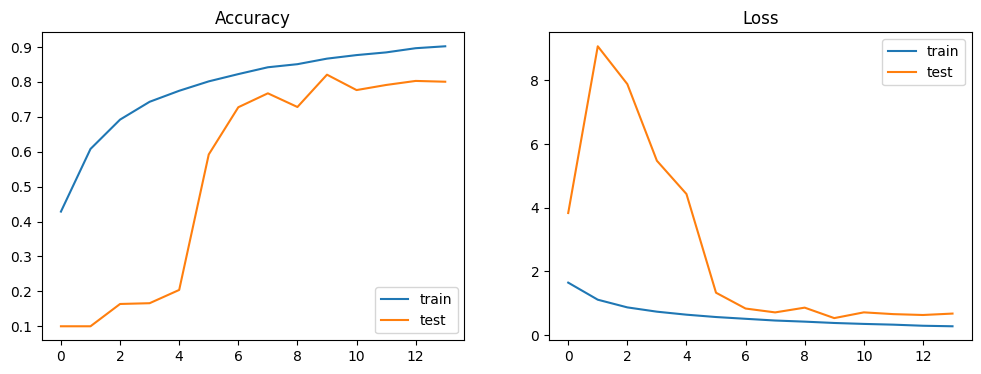

Elapsed time training = 33.8922 secs
Accuracy = 0.8208


In [34]:
earlystopping = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=4,
    restore_best_weights=True
)


def cnn(
    input_shape,
    conv_units,
    dense_units,
    out_units,
    dropout_rate=0.25
):

    model = tf.keras.Sequential()

    model.add(Input(shape=input_shape))

    for c in conv_units:

        model.add(
            Conv2D(
                c,
                kernel_size=(3, 3),
                activation='relu',
                padding='same',
                kernel_regularizer=regularizers.L1L2(
                    l1=0,
                    l2=0
                )
            )
        )

        model.add(
            Conv2D(
                c,
                kernel_size=(3, 3),
                activation='relu',
                padding='same',
                kernel_regularizer=regularizers.L1L2(
                    l1=0,
                    l2=0
                )
            )
        )

        model.add(
            MaxPooling2D(
                pool_size=(2, 2)
            )
        )

        model.add(
            BatchNormalization()
        )

        model.add(
            Dropout(dropout_rate)
        )

    model.add(
        Flatten()
    )

    model.add(
        Dense(
            dense_units,
            activation='relu',
            kernel_regularizer=regularizers.L1L2(
                l1=0,
                l2=0
            )
        )
    )

    model.add(
        BatchNormalization()
    )

    model.add(
        Dropout(dropout_rate)
    )

    model.add(
        Dense(
            out_units,
            activation='softmax'
        )
    )

    return model


# Number of CIFAR-10 classes
num_classes = int(np.max(y_train) + 1)

print("Number of classes:", num_classes)
print("Type:", type(num_classes))


# Build model
model = cnn(
    X_train.shape[1:],
    [50, 100, 200],
    100,
    num_classes
)

model.summary()


# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# Train model
start_train = time.time()

history = model.fit(
    X_train,
    y_train,
    epochs=200,
    batch_size=500,
    verbose=2,
    validation_data=(X_test, y_test),
    callbacks=[earlystopping]
)

end_train = time.time()


# Plot results
plot_results(history)


# Prediction
pred = model.predict(
    X_test,
    verbose=0
)


print(
    'Elapsed time training = {:.4f} secs'.format(
        end_train - start_train
    )
)


# Convert probabilities to predicted class labels
pred_int = np.argmax(
    pred,
    axis=1
)


# Test accuracy
accuracy = accuracy_score(
    y_test.ravel(),
    pred_int
)

print(
    'Accuracy = {:.4f}'.format(
        accuracy
    )
)